In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.plot import plot_graph
import random as rng

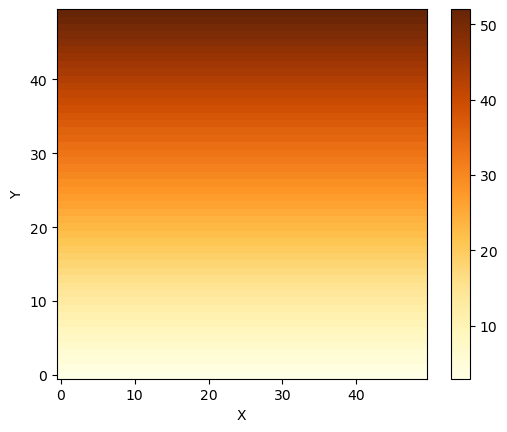

In [2]:
num_rows = 50  # number of grid rows
num_cols = 50  # number of grid columns
dxy = 1  # resolution of raster cell [m], or node horizontal and vertical spacing
grid = RasterModelGrid((num_rows, num_cols), dxy)

#create the initial simplified ramp topography
topo = grid.add_zeros('topographic__elevation', at='node')
cliff_height = 3 #working in meters
for i in range(num_rows):
    start = i * num_rows
    end = start + num_rows
    topo[start:end] = cliff_height
    cliff_height += 1
    
# Plot the topo map
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

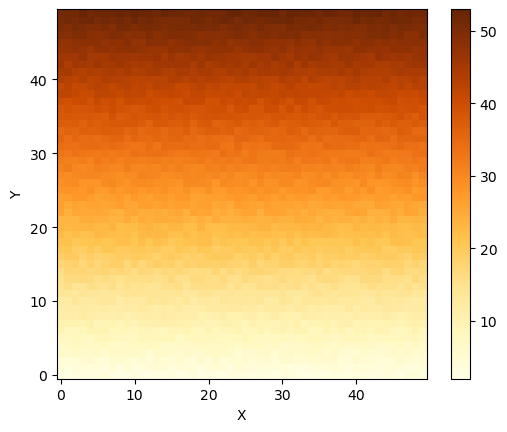

In [3]:
topo_noise = np.random.uniform(-1, 1, 2500)
topo += topo_noise

# Plot the topo map with noise
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

In [4]:
sea_level = 6.0 #meters
erosion_rate = 10  #m/y or set zr[i] = sea_level to cut/flatten directly
uplift_rate_m_yr = 2.1/1000 # 2.1 mm/yr avg uplift
dt = 10 # timestep (yr)
uplift = uplift_rate_m_yr * dt
time_to_run = 1e3  # time for the model loop to run [yr]
nsteps = int(time_to_run / dt)  # number of model time steps

In [5]:
for step in range (nsteps):
    # Loop over every node on the grid (removed the + 1)
    for i in range(grid.number_of_nodes):
        topo[i]+= uplift
        if topo[i] < sea_level:
            topo[i] -= erosion_rate  # Erode node if it is underwater

In [9]:
from matplotlib import cm
import matplotlib.colors as mcolors

def surf_plot(grid, surface="topographic__elevation", units='m', title="Topographic Elevation (3D)", elev=20, azim=-150, ax=None, cmap="YlOrBr", vmin=None, vmax=None):
   
    single_fig = ax is None
    if single_fig:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_axes([0.05, 0.05, 0.75, 0.90], projection="3d") # for some reason this plot cuts off the z-axis label for certain 
                                                                      # orientations (azim=-70) so this forces it to a specific position for some of them 
    else:
        fig = ax.get_figure()
    # plot the surface
    z = grid.at_node[surface].reshape(grid.shape)

    # Use provided vmin/vmax if given, otherwise fall back to this data's own min/max
    if vmin is not None:
        zmin = vmin
    else:
        zmin = z.min()
    if vmax is not None:
        zmax = vmax
    else:
        zmax = z.max()

    norm = mcolors.Normalize(vmin=zmin, vmax=zmax)
    surf = ax.plot_surface(
                grid.x_of_node.reshape(grid.shape),
                grid.y_of_node.reshape(grid.shape),
                z,
                cmap=cmap,
                norm=norm,
                linewidth=0.0,
                antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel(f"x [{units}]")
    ax.set_ylabel(f"y [{units}]")
    ax.set_zlabel(f"elevation [{units}]")
    plt.title(title)
    fig.colorbar(surf, ax=ax, label=f"elevation [{units}]")
    if single_fig:
        plt.show()


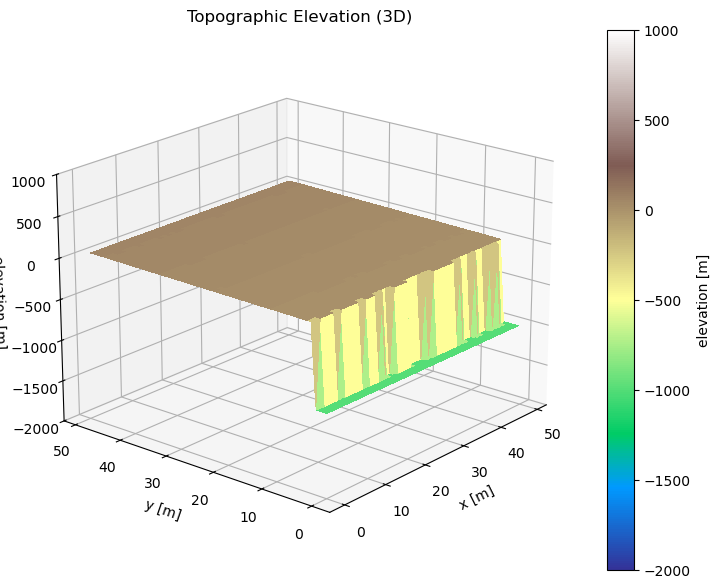

In [8]:
surf_plot(grid, azim=220,cmap='terrain', vmin=-2000, vmax=1000)